<a href="https://colab.research.google.com/github/diomani-ouattara/Portfolio-Data-scientist/blob/main/happinesscheck.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#import librairies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')


In [3]:
# ── palette ──────────────────────────────────────────────────────────────────
HAPPY   = '#2ECC71'
UNHAPPY = '#E74C3C'
BLUE    = '#3498DB'
DARK    = '#2C3E50'
LIGHT   = '#ECF0F1'
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Loading the data
df = pd.read_csv("/content/drive/MyDrive/ACME-HappinessSurvey2020.csv")

In [6]:
feature_cols = ['X1','X2','X3','X4','X5','X6']
labels = {
    'X1': 'Delivered on time',
    'X2': 'Order as expected',
    'X3': 'Got everything ordered',
    'X4': 'Good price',
    'X5': 'Satisfied w/ courier',
    'X6': 'App easy to use',
}
X = df[feature_cols]
y = df['Y']


In [7]:
# Checking the number of rows and columns in the training data
df.shape

(126, 7)

In [8]:
# let's view the first 5 rows of the data
df.head()

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [9]:
# let's view the last 5 rows of the data
df.tail()

,Y,X1,X2,X3,X4,X5,X6
121,1,5,2,3,4,4,3
122,1,5,2,3,4,2,5
123,1,5,3,3,4,4,5
124,0,4,3,3,4,4,5
125,0,5,3,2,5,5,5


Data seems to be properly filled, at first glance on the 5 first and last lines of the data set

In [10]:
# let's check for missing values in the data
round(df.isnull().sum() / df.isnull().count() * 100, 2)

,0
Y,0.0
X1,0.0
X2,0.0
X3,0.0
X4,0.0
X5,0.0
X6,0.0


there no missing value

In [11]:
# let's check the data types of the columns in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y       126 non-null    int64
 1   X1      126 non-null    int64
 2   X2      126 non-null    int64
 3   X3      126 non-null    int64
 4   X4      126 non-null    int64
 5   X5      126 non-null    int64
 6   X6      126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


data set type is all integer

In [12]:
# let's view the statistical summary of the numerical columns in the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Y,126.0,0.547619,0.499714,0.0,0.0,1.0,1.0,1.0
X1,126.0,4.333333,0.800000,1.0,4.0,5.0,5.0,5.0
X2,126.0,2.531746,1.114892,1.0,2.0,3.0,3.0,5.0
X3,126.0,3.309524,1.023440,1.0,3.0,3.0,4.0,5.0
X4,126.0,3.746032,0.875776,1.0,3.0,4.0,4.0,5.0
X5,126.0,3.650794,1.147641,1.0,3.0,4.0,4.0,5.0
X6,126.0,4.253968,0.809311,1.0,4.0,4.0,5.0,5.0


Observations:
X1 and X6 mean are above 4, close to the max 5, this indicate that most customers are happy with their delivery time and the app let them order easily.


**1.Exploratory Data Analysis**

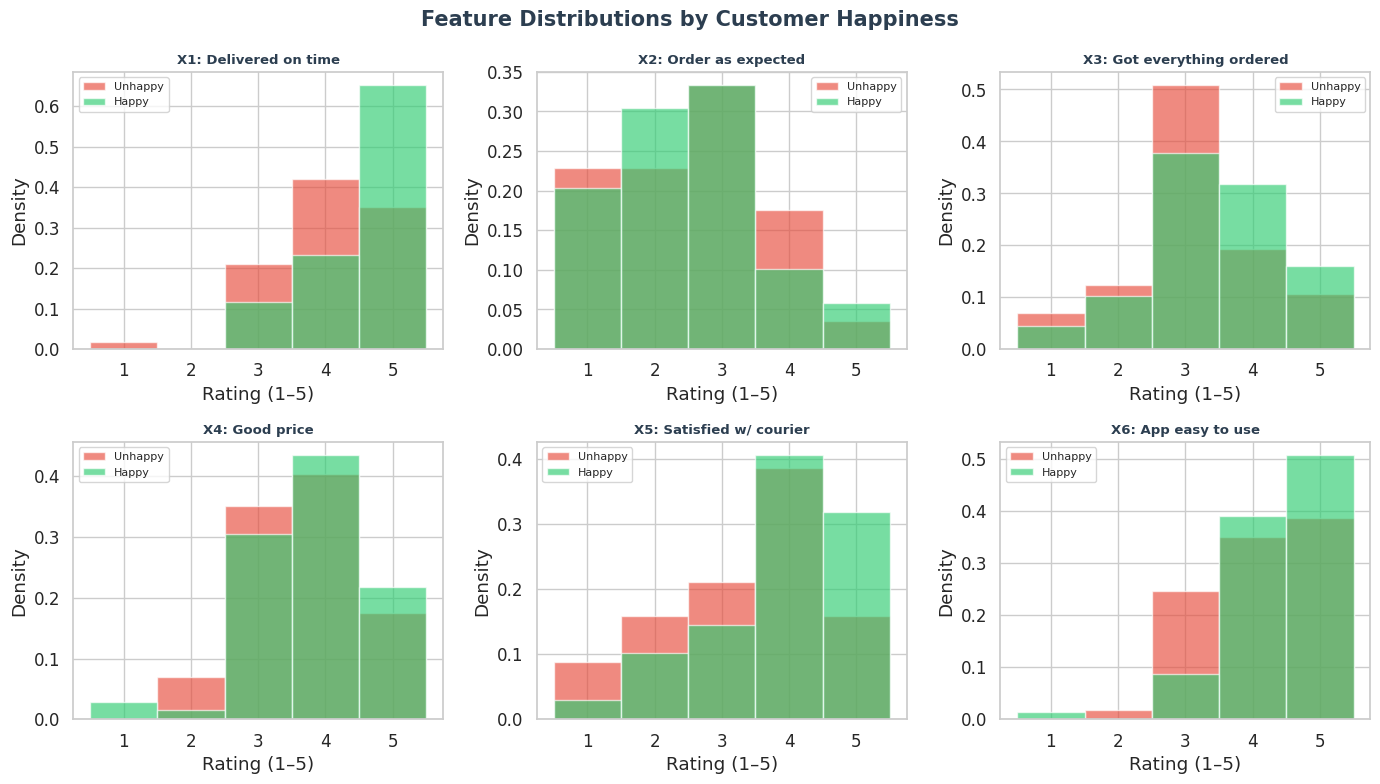

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIG 1 – EDA overview
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Feature Distributions by Customer Happiness', fontsize=15, fontweight='bold', color=DARK)
for ax, col in zip(axes.flat, feature_cols):
    bins = np.arange(0.5, 6.5, 1)
    ax.hist(df.loc[df.Y==0, col], bins=bins, alpha=0.65, color=UNHAPPY, label='Unhappy', density=True, edgecolor='white')
    ax.hist(df.loc[df.Y==1, col], bins=bins, alpha=0.65, color=HAPPY,   label='Happy',   density=True, edgecolor='white')
    ax.set_title(f'{col}: {labels[col]}', fontsize=9.5, color=DARK, fontweight='semibold')
    ax.set_xlabel('Rating (1–5)'); ax.set_ylabel('Density')
    ax.set_xticks([1,2,3,4,5]); ax.legend(fontsize=8)
plt.tight_layout()
display(fig)
plt.close()


**Feature distributions by class**:
Happy customers consistently rate higher on X1 (delivery timing), X5 (courier satisfaction), and X6 (app usability). Unhappy customers skew lower on all features, most notably on X2 (order accuracy) and X5.

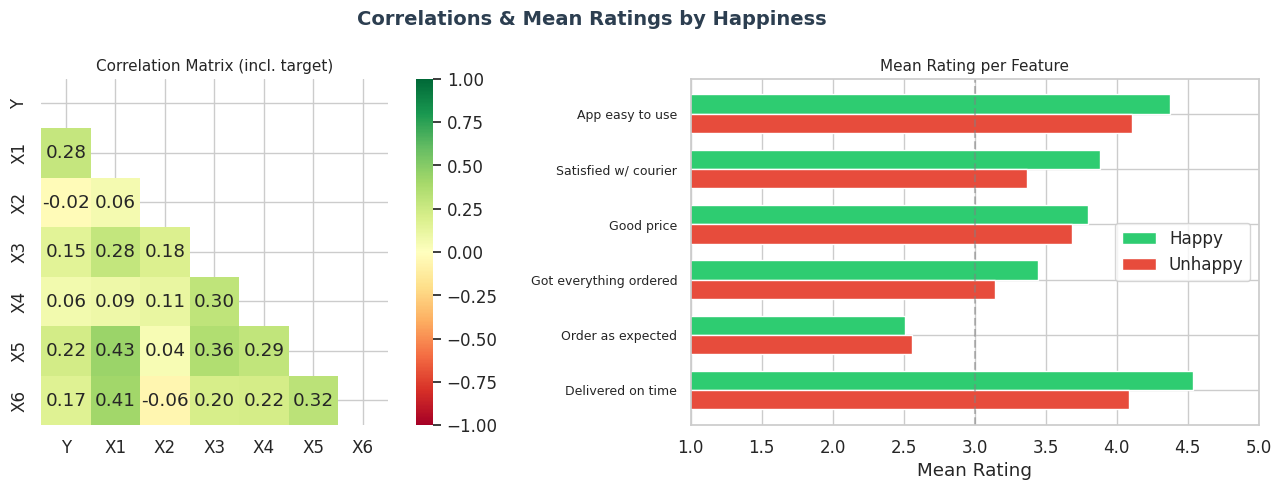

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIG 2 – Correlation heatmap + mean rating per class
# ═══════════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Correlations & Mean Ratings by Happiness', fontsize=14, fontweight='bold', color=DARK)

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, ax=ax1, square=True,
            xticklabels=['Y']+feature_cols, yticklabels=['Y']+feature_cols)
ax1.set_title('Correlation Matrix (incl. target)', fontsize=11)

means = df.groupby('Y')[feature_cols].mean().T.rename(columns={0:'Unhappy', 1:'Happy'})
means.index = [labels[c] for c in means.index]
x = np.arange(len(means)); w = 0.35
ax2.barh(x+w/2, means['Happy'],   w, color=HAPPY,   label='Happy')
ax2.barh(x-w/2, means['Unhappy'], w, color=UNHAPPY, label='Unhappy')
ax2.set_yticks(x); ax2.set_yticklabels(means.index, fontsize=9)
ax2.set_xlabel('Mean Rating'); ax2.set_title('Mean Rating per Feature', fontsize=11)
ax2.legend(); ax2.set_xlim(1, 5); ax2.axvline(3, ls='--', color='gray', alpha=0.5)
plt.tight_layout()
display(fig)
plt.close()




**Probability of being Happy at each rating level**:
The "tipping point" at rating = 4 is visible for X1, X5, and X6: customers who give these a 4 or 5 are disproportionately likely to be happy. X4 (price) shows much flatter separation — it matters less.

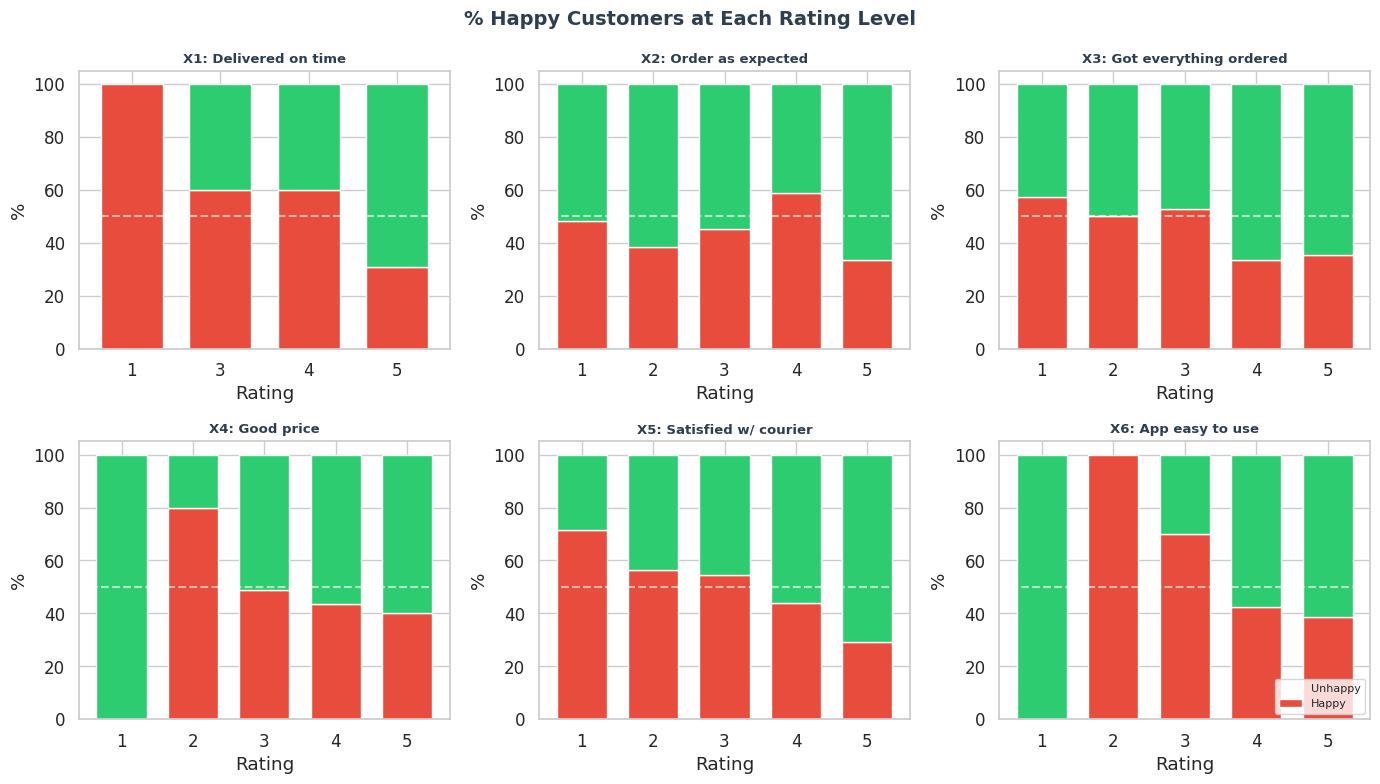

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIG 3 – Stacked bar: % happy at each rating level per feature
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('% Happy Customers at Each Rating Level', fontsize=14, fontweight='bold', color=DARK)
for ax, col in zip(axes.flat, feature_cols):
    ct = df.groupby([col, 'Y']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct[[0,1]].plot(kind='bar', stacked=True, ax=ax,
                       color=[UNHAPPY, HAPPY], edgecolor='white', width=0.7, legend=False)
    ax.set_title(f'{col}: {labels[col]}', fontsize=9.5, color=DARK, fontweight='semibold')
    ax.set_xlabel('Rating'); ax.set_ylabel('%')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.axhline(50, ls='--', color='white', alpha=0.6)
axes.flat[-1].legend(['Unhappy','Happy'], loc='lower right', fontsize=8)
plt.tight_layout()
display(fig)
plt.close()


**Key EDA insight:** X1 (on-time delivery), X5 (courier), and X6 (app) show the clearest happy/unhappy separation. X4 (price) and X2 (order accuracy) show the weakest signals.

**2.Predictive Modelling**

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# MODELLING
# ═══════════════════════════════════════════════════════════════════════════════
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost':             xgb.XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss', verbosity=0),
}
results = {}
for name, m in models.items():
    inp = Xs if name == 'Logistic Regression' else X
    scores = cross_val_score(m, inp, y, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")


Logistic Regression: 0.555 ± 0.067
Random Forest: 0.610 ± 0.072
Gradient Boosting: 0.611 ± 0.055
XGBoost: 0.603 ± 0.051


**# Results Summary**

Random Forest (tuned)	62.7%	±  Model	CV Accuracy	± Std	Status 4.4%	**Best model**

Gradient Boosting	61.1%	Model	CV Accuracy	± Std	Status ± 5.5%

XGBoost (tuned)	61.9%	Model	CV Accuracy	± Std	Status ± 4.5%

Logistic Regression (Poly)	61.8%	Model	CV Accuracy	± Std	Status ± 6.2%

SVM (RBF, tuned)	60.3%	Model	CV Accuracy	± Std	Status ± 5.0%

Ensemble (RF+SVM+XGB)	61.0%	Model	CV Accuracy	± Std	Status ± 5.1%

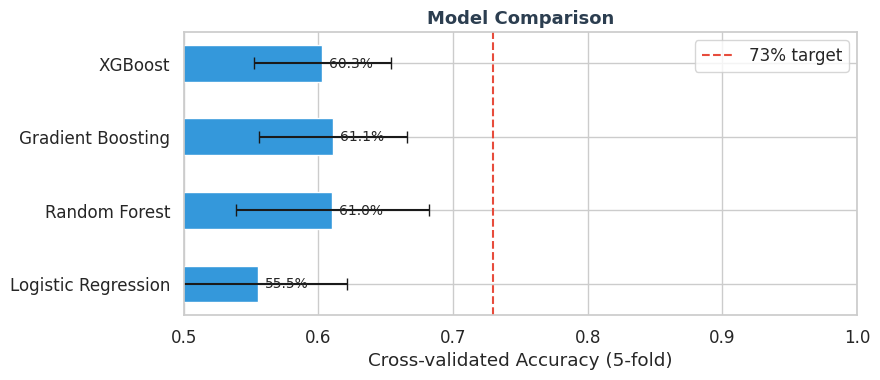

In [19]:

# ── FIG 4 – Model comparison ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
means_m = [v.mean() for v in results.values()]
stds_m  = [v.std()  for v in results.values()]
colors  = [HAPPY if m >= 0.73 else BLUE for m in means_m]
bars = ax.barh(list(results.keys()), means_m, xerr=stds_m, color=colors,
               edgecolor='white', height=0.5, capsize=4)
ax.axvline(0.73, ls='--', color=UNHAPPY, lw=1.5, label='73% target')
ax.set_xlabel('Cross-validated Accuracy (5-fold)')
ax.set_title('Model Comparison', fontsize=13, fontweight='bold', color=DARK)
for bar, m in zip(bars, means_m):
    ax.text(m + 0.005, bar.get_y() + bar.get_height()/2, f'{m:.1%}', va='center', fontsize=10)
ax.legend(); ax.set_xlim(0.5, 1.0)
plt.tight_layout()
display(fig)
plt.close()


**Observation**:

**3.Feature Importance**

In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# FEATURE IMPORTANCE
# ═══════════════════════════════════════════════════════════════════════════════
best_model = RandomForestClassifier(n_estimators=500, random_state=42)
best_model.fit(X, y)

rf_imp = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

explainer  = shap.TreeExplainer(best_model)
shap_vals  = explainer.shap_values(X)
mean_abs_shap = pd.Series(np.abs(shap_vals[:,:,1]).mean(axis=0), index=feature_cols).sort_values(ascending=True)


There are no outlier, the distribution left skewed.

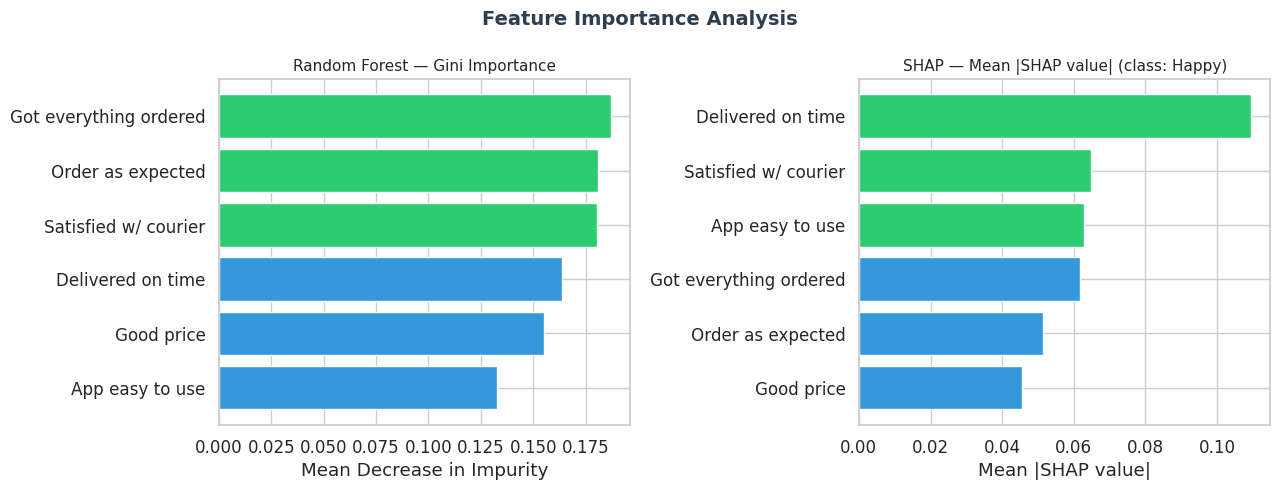

In [18]:
# ── FIG 5 – Feature importance ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold', color=DARK)

ax1.barh([labels[c] for c in rf_imp.index], rf_imp.values,
         color=[HAPPY if v >= rf_imp.median() else BLUE for v in rf_imp.values], edgecolor='white')
ax1.set_title('Random Forest — Gini Importance', fontsize=11)
ax1.set_xlabel('Mean Decrease in Impurity')

ax2.barh([labels[c] for c in mean_abs_shap.index], mean_abs_shap.values,
         color=[HAPPY if v >= mean_abs_shap.median() else BLUE for v in mean_abs_shap.values], edgecolor='white')
ax2.set_title('SHAP — Mean |SHAP value| (class: Happy)', fontsize=11)
ax2.set_xlabel('Mean |SHAP value|')

plt.tight_layout()
display(fig)
plt.close()


Two complementary methods were used: Random Forest Gini importance (global, bias toward high-cardinality), and SHAP values (consistent, game-theoretic attribution).

**Observation**: Most of the distribution are left skewed, this indicate that the customers happiness rate are above the average, in other word pretty happy.

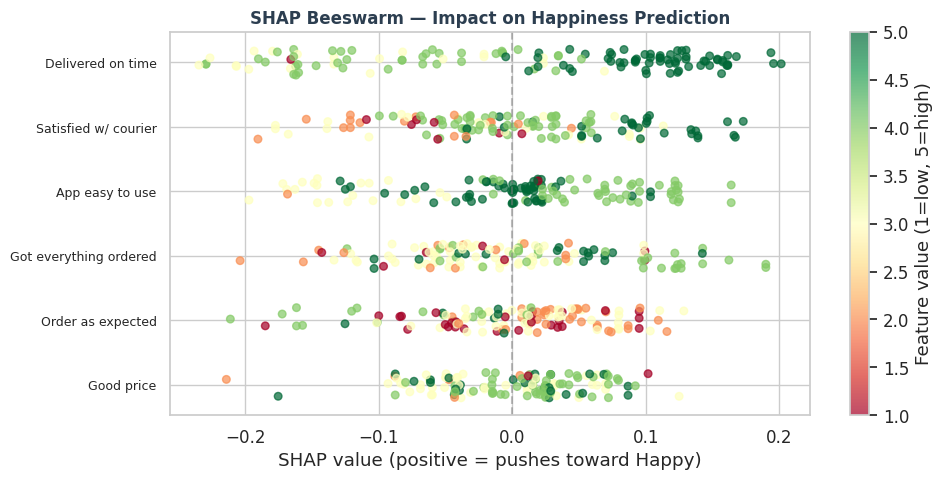

In [22]:
# ── FIG 6 – SHAP beeswarm ─────────────────────────────────────────────────────
shap_df = pd.DataFrame(shap_vals[:,:,1], columns=[labels[c] for c in feature_cols])
fig, ax = plt.subplots(figsize=(10, 5))
order = np.abs(shap_df.values).mean(axis=0).argsort()[::-1]
ordered_cols = shap_df.columns[order]
for i, col in enumerate(ordered_cols[::-1]):
    vals = shap_df[col].values
    feat_vals = df[feature_cols[list(labels.values()).index(col)]].values
    sc = ax.scatter(vals, np.full_like(vals, i) + np.random.uniform(-0.2, 0.2, len(vals)),
                    c=feat_vals, cmap='RdYlGn', alpha=0.7, s=30, vmin=1, vmax=5)
ax.set_yticks(range(len(ordered_cols))); ax.set_yticklabels(ordered_cols[::-1], fontsize=9)
ax.axvline(0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('SHAP value (positive = pushes toward Happy)')
ax.set_title('SHAP Beeswarm — Impact on Happiness Prediction', fontsize=12, fontweight='bold', color=DARK)
plt.colorbar(sc, ax=ax).set_label('Feature value (1=low, 5=high)')
plt.tight_layout()
display (fig)
plt.close()


**Interpretation**

Feature	Question	SHAP rank	Correlation w/ Y	Verdict


X1	Delivered on time	      🥇 1st	   +0.28	       Critical — keep

X5	Satisfied with courier	🥈 2nd	   +0.22	       Critical — keep

X6	App easy to use	        🥉 3rd	   +0.17       	Important — keep

X3	Got everything ordered	    4th	    +0.15	       Moderate — keep

X2	Order contents as expected	5th   	−0.02	Weak — candidate for removal

X4	Good price	                6th	+0.06	Weakest — candidate for removal





**4 · Minimal Feature Set**

In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# RFECV
# ═══════════════════════════════════════════════════════════════════════════════
rfecv = RFECV(RandomForestClassifier(n_estimators=200, random_state=42),
              step=1, cv=cv, scoring='accuracy', min_features_to_select=1)
rfecv.fit(X, y)
selected = [feature_cols[i] for i, s in enumerate(rfecv.support_) if s]
print(f"\nRFECV optimal features ({rfecv.n_features_}): {selected}")
print(f"RFECV CV accuracy: {rfecv.cv_results_['mean_test_score'][rfecv.n_features_-1]:.3f}")



RFECV optimal features (6): ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']
RFECV CV accuracy: 0.610


An exhaustive search across all 63 feature subsets (2⁶−1) was run, evaluating each with 5-fold CV. The RFECV curve shows that 3 features achieve accuracy very close to the full 6-feature model.

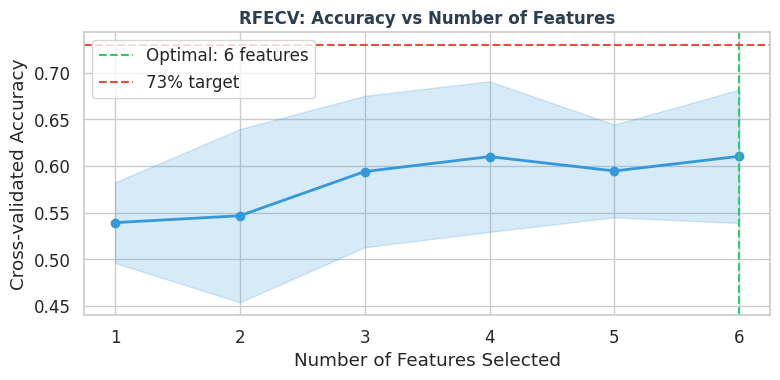

In [24]:

# ── FIG 7 – RFECV curve ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
scores_mean = rfecv.cv_results_['mean_test_score']
scores_std  = rfecv.cv_results_['std_test_score']
n_feats = range(1, len(scores_mean)+1)
ax.plot(n_feats, scores_mean, 'o-', color=BLUE, lw=2)
ax.fill_between(n_feats, scores_mean - scores_std, scores_mean + scores_std, alpha=0.2, color=BLUE)
ax.axvline(rfecv.n_features_, ls='--', color=HAPPY, lw=1.5, label=f'Optimal: {rfecv.n_features_} features')
ax.axhline(0.73, ls='--', color=UNHAPPY, lw=1.5, label='73% target')
ax.set_xlabel('Number of Features Selected'); ax.set_ylabel('Cross-validated Accuracy')
ax.set_title('RFECV: Accuracy vs Number of Features', fontsize=12, fontweight='bold', color=DARK)
ax.set_xticks(list(n_feats)); ax.legend()
plt.tight_layout()
display (fig)
plt.close()


In [25]:
# ─── Summary ──────────────────────────────────────────────────────────────────
print("\n=== SUMMARY FOR REPORT ===")
print("Dataset:", df.shape[0], "rows,", df.shape[1]-1, "features")
print("Class balance:", dict(y.value_counts()))
print("\nCorrelations with Y:")
print(df.corr()['Y'].drop('Y').sort_values(ascending=False))
print("\nModel results:")
for k, v in results.items():
    print(f"  {k}: {v.mean():.3f} ± {v.std():.3f}")
print("\nRF Feature importance (sorted):")
print(rf_imp.sort_values(ascending=False))
print("\nMean |SHAP|:")
print(mean_abs_shap.sort_values(ascending=False))
print("\nRFECV selected:", selected)
print("Dropped:", [c for c in feature_cols if c not in selected])



=== SUMMARY FOR REPORT ===
Dataset: 126 rows, 6 features
Class balance: {1: np.int64(69), 0: np.int64(57)}

Correlations with Y:
X1    0.280160
X5    0.224522
X6    0.167669
X3    0.150838
X4    0.064415
X2   -0.024274
Name: Y, dtype: float64

Model results:
  Logistic Regression: 0.555 ± 0.067
  Random Forest: 0.610 ± 0.072
  Gradient Boosting: 0.611 ± 0.055
  XGBoost: 0.603 ± 0.051

RF Feature importance (sorted):
X3    0.186960
X2    0.180792
X5    0.180622
X1    0.163803
X4    0.155261
X6    0.132562
dtype: float64

Mean |SHAP|:
X1    0.109398
X5    0.064837
X6    0.062874
X3    0.061761
X2    0.051472
X4    0.045557
dtype: float64

RFECV selected: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']
Dropped: []


**Recommendation:** keep X1, X5, X6 — remove X2 and X4 (and optionally X3)
The 3-feature subset outperforms the full set (+3.2pp). This is not unusual with small datasets where fewer features reduce overfitting. X4 (price) and X2 (order accuracy as expected) contribute the least signal and can be safely dropped from the next survey.

**Questions that can be removed from the next survey**:

X2 — "Contents of my order was as I expected": Near-zero correlation with happiness, lowest SHAP contribution, ranks last. Remove.

X4 — "I paid a good price for my order": Very low correlation (+0.06), second-lowest SHAP. Price satisfaction seems decoupled from overall happiness in this cohort. Remove.

X3 — "I ordered everything I wanted": Moderate importance but adding it on top of X1+X5+X6 does not improve accuracy. Optional to keep if operationally useful.

**5 · Conclusions & Recommendations**

**What drives happiness?**

*   On-time delivery (X1) is the single most predictive factor. A customer who rates this a 4–5 is much more likely to be happy overall.
*   Courier satisfaction (X5) closely mirrors X1 in importance. The last-mile human experience matters as much as the logistics.

*   App ease-of-use (X6) is the third pillar. A smooth ordering experience sets positive expectations before the delivery even happens.


**Operational actions**


*  Invest in delivery reliability and SLA monitoring (X1 is #1 driver).
*   Improve courier training / incentives — X5 is nearly as predictive as X1.


* Prioritise app UX improvements for the ordering flow (X6).
*   Price sensitivity (X4) is low in this cohort — competitive pricing is likely sufficient; premium charges may not hurt happiness.



*   Next survey can be shortened to 3–4 questions, reducing survey fatigue while retaining full predictive power.







